# Tick data cleaning: find it, preview the fix, keep the audit trail

Raw vendor tick files arrive dirty. Fat-finger prints 10x off, zero prices
from feed glitches, duplicated blocks from replayed packets, after-hours junk.

The dangerous part is not detection. It is the *fix*. A script that UPDATEs
ticks in place leaves you unable to say what changed, when, or how to undo it.

h5i-db's answer is the plan/apply flow. Every mutation is staged as a
previewable plan carrying row counts and before/after samples, applied as an
atomic commit with a note, and reversible via `restore()`.

In this recipe we:

1. pollute two days of trades with four defect classes,
2. find each class with one SQL query,
3. repair them with a delete plan and a replace plan,
4. lock the table down so direct, unreviewed mutations become policy
   violations.

## Terms used here

| term             | meaning |
| ---------------- | --- |
| tick             | one event on a market data feed, usually a trade or a quote update |
| fat-finger print | a trade recorded at an obviously wrong price, e.g. 10x off |
| outlier          | an observation far enough from the rest to be suspected bad rather than rare |
| plan / apply     | stage a delete or replace, review its row counts and samples, then commit it |
| mutation policy  | a database-level setting that blocks direct destructive writes |
| `restore`        | roll back by committing an old version forward, so history grows rather than shrinks |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, count_star, lit, sql_expr, time_bucket, when
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("mde_cleaning"), create=True)

## 1. The data

Two clean sessions of ticks from `cu.make_trades`, one row per print.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | trade timestamp, ascending |
| `symbol` | `string` | ticker |
| `price` | `float64` | trade price |
| `size` | `int64` | shares traded |
| `exchange` | `string` | reporting venue |
| `side` | `string` | `B` buyer-initiated, `S` seller-initiated |

In [2]:
trades = cu.make_trades(symbols=["AAPL", "MSFT", "NVDA"], days=2, trades_per_day=20_000, seed=7).to_pandas()
print(f"{len(trades):,} rows x {trades.shape[1]} columns")
trades.head()

118,219 rows x 6 columns


,ts,symbol,price,size,exchange,side
0,2026-06-01 13:30:00.669981+00:00,AAPL,265.05,1,ARCA,B
1,2026-06-01 13:30:00.865263+00:00,MSFT,362.97,1,IEX,S
2,2026-06-01 13:30:01.023598+00:00,NVDA,319.28,1,IEX,B
3,2026-06-01 13:30:01.117852+00:00,AAPL,265.01,1,BATS,S
4,2026-06-01 13:30:01.135445+00:00,MSFT,362.97,100,IEX,S


Now we manufacture a dirty vendor drop from it. Four defect classes go in
under a fixed seed:

- **fat fingers**, 25 prints at 10x, inside one 15-minute window;
- **zero prices**, 6 prints in the same window;
- **a replayed packet**, 30 prints duplicated exactly;
- **after-hours junk**, 40 prints at 22:00 UTC, two hours after the session
  closes.

In [3]:
rng = np.random.default_rng(99)

DAY1 = pd.Timestamp("2026-06-01", tz="UTC")
W0 = DAY1 + pd.Timedelta(hours=15)            # polluted window: 15:00-15:15 UTC
W1 = DAY1 + pd.Timedelta(minutes=15) + pd.Timedelta(hours=15)

in_win = trades.index[(trades["ts"] >= W0) & (trades["ts"] < W1)].to_numpy()
ff = rng.choice(in_win, 25, replace=False)                                # fat fingers
zr = rng.choice(np.setdiff1d(in_win, ff), 6, replace=False)               # zero prices
dp = rng.choice(np.setdiff1d(in_win, np.concatenate([ff, zr])), 30, replace=False)

trades.loc[ff, "price"] = (trades.loc[ff, "price"] * 10).round(2)
trades.loc[zr, "price"] = 0.0
dup_block = trades.loc[dp].copy()                                         # replayed packet

day1_last = trades[trades["ts"] < DAY1 + pd.Timedelta(hours=20)].groupby("symbol")["price"].last()
ooh_syms = rng.choice(["AAPL", "MSFT", "NVDA"], 40)
after_hours = pd.DataFrame(
    {
        "ts": DAY1 + pd.Timedelta(hours=22, minutes=5)
        + pd.to_timedelta(np.sort(rng.integers(0, 45 * 60, 40)), unit="s"),
        "symbol": ooh_syms,
        "price": (day1_last.loc[ooh_syms].to_numpy() * (1 + rng.normal(0, 1e-3, 40))).round(2),
        "size": (rng.lognormal(4, 1, 40) // 100 * 100 + 100).astype("int64"),
        "exchange": rng.choice(["NYSE", "ARCA"], 40),
        "side": rng.choice(["B", "S"], 40),
    }
)

dirty = (
    pd.concat([trades, dup_block, after_hours])
    .sort_values(["ts", "symbol"], kind="stable")
    .reset_index(drop=True)
)
print(f"{len(dirty):,} rows including {len(dup_block)} duplicates and {len(after_hours)} after-hours prints")

118,289 rows including 30 duplicates and 40 after-hours prints


Ingest day by day, one commit per vendor file. The commit boundary *is* the
provenance boundary, and the notes say which file each version came from.

In [4]:
TRADE_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("price", pa.float64()),
        pa.field("size", pa.int64()),
        pa.field("exchange", pa.string()),
        pa.field("side", pa.string()),
    ]
)
db.create_table("trades", TRADE_SCHEMA, time_column="ts", sort_key=["ts", "symbol"])
for day, label in [("2026-06-01", "day 1"), ("2026-06-02", "day 2")]:
    chunk = dirty[dirty["ts"].dt.date == pd.Timestamp(day).date()]
    db.append("trades", pa.Table.from_pandas(chunk, preserve_index=False).cast(TRADE_SCHEMA),
              note=f"vendor file {day}")
V_RAW = db.versions("trades")[-1]["sequence"]  # the as-delivered state, for auditing later
print("as-delivered head version:", V_RAW)

as-delivered head version: 2


## 2. Detection, one query per defect class

Zero prices are a plain predicate.

Fat fingers stand out against a robust local reference: the 5-minute
per-symbol median via `approx_percentile_cont`, rather than a mean that the
outlier itself drags around.

In [5]:
(
    db.table("trades")
    .filter(col("price") <= 0)
    .group_by("symbol")
    .agg(zero_price_prints=count_star())
    .to_pandas()
)

,symbol,zero_price_prints
0,NVDA,2
1,AAPL,4


In [6]:
W5 = time_bucket("5m", col("ts"))

ref = (
    db.table("trades")
    .filter(col("price") > 0)
    .group_by(W5.alias("w"), "symbol")
    .agg(med=sql_expr("approx_percentile_cont(price, 0.5)"))
)

px, ref_med = col("price", relation="l"), col("med", relation="r")

fat = (
    db.table("trades")
    .with_columns(w=W5)
    .join(ref, on=["w", "symbol"])
    .filter(px > 3 * ref_med)
    .select(
        ts=col("ts", relation="l"),
        symbol=col("symbol", relation="l"),
        price=px,
        local_median=ref_med.round(2),
        ratio=(px / ref_med).round(1),
    )
    .sort("ts")
    .to_pandas()
)
print(f"{len(fat)} suspected fat fingers, ratios ~{fat['ratio'].min()}-{fat['ratio'].max()}x")
fat.head(5)

25 suspected fat fingers, ratios ~10.0-10.0x


,ts,symbol,price,local_median,ratio
0,2026-06-01 15:01:25.987031+00:00,MSFT,3587.6,358.51,10.0
1,2026-06-01 15:02:13.485780+00:00,AAPL,2665.3,266.52,10.0
2,2026-06-01 15:03:24.064636+00:00,NVDA,3183.5,318.32,10.0
3,2026-06-01 15:04:05.174954+00:00,NVDA,3183.4,318.32,10.0
4,2026-06-01 15:04:13.744335+00:00,MSFT,3580.9,358.51,10.0


Replayed packets show up as *exact* duplicate rows. After-hours junk is an
`EXTRACT(hour ...)` predicate against the 13:30-20:00 UTC session.

In [7]:
(
    db.table("trades")
    .group_by("ts", "symbol", "price", "size", "exchange", "side")
    .count("n")
    .filter(col("n") > 1)  # the HAVING, one level up
    .select(dup_groups=count_star(), excess_rows=(col("n") - 1).sum())
    .to_pandas()
)

,dup_groups,excess_rows
0,30,30


In [8]:
HOUR = sql_expr("EXTRACT(hour FROM ts)")
AFTER_HOURS = (HOUR >= 20) | (HOUR < 13)

(
    db.table("trades")
    .filter(AFTER_HOURS)
    .select(first_print=col("ts").min(), last_print=col("ts").max(), n=count_star())
    .to_pandas()
)

,first_print,last_print,n
0,2026-06-01 22:05:34+00:00,2026-06-01 22:49:00+00:00,40


## 3. Fix 1: delete the after-hours block, with a preview

`plan_delete_range` stages the mutation without touching the table. The range
is a raw `int64` window in the time column's unit, microseconds here.

The summary and `before_sample` tell you exactly what would disappear. Review
the blast radius before anything changes.

In [9]:
OOH0 = int(pd.Timestamp("2026-06-01 22:00", tz="UTC").value // 1_000)
OOH1 = int(pd.Timestamp("2026-06-01 23:00", tz="UTC").value // 1_000)

plan = db.plan_delete_range("trades", OOH0, OOH1, note="drop after-hours junk 2026-06-01")
plan.summary

{'rows_before': 118289,
 'rows_after': 118249,
 'rows_affected': 40,
 'segments_reused': 1,
 'segments_added': 1,
 'added_bytes': 369575,
 'affected_time_range': [1780351200000000, 1780354800000000]}

In [10]:
plan.before_sample.to_pandas().head(4)

,ts,symbol,price,size,exchange,side
0,2026-06-01 22:05:34+00:00,MSFT,354.27,300,NYSE,S
1,2026-06-01 22:06:47+00:00,AAPL,266.61,200,ARCA,S
2,2026-06-01 22:07:10+00:00,NVDA,314.81,100,NYSE,B
3,2026-06-01 22:09:16+00:00,NVDA,315.25,200,ARCA,S


In [11]:
plan.apply()

{'table': 'trades',
 'sequence': 3,
 'op': 'delete_range',
 'rows_total': 118249,
 'segments_total': 2,
 'segments_added': 1,
 'segments_deduped': 1,
 'committed_at_ns': 1785448827922420090}

## 4. Fix 2: replace the polluted window with repaired data

For the 15:00-15:15 window we do not want a delete. We want the *corrected*
prints: fat fingers scaled back by 10, zero prices dropped, duplicates
collapsed.

So we pull the window, repair it in pandas, and stage a `plan_replace_range`
with the repaired rows. The before and after samples make the correction
reviewable line by line.

In [12]:
W0_US, W1_US = int(W0.value // 1_000), int(W1.value // 1_000)

win = (
    db.table("trades")
    .filter(col("ts") >= W0.isoformat(), col("ts") < W1.isoformat())
    .sort(["ts", "symbol"])
    .to_pandas()
)

med = win[win["price"] > 0].groupby("symbol")["price"].median()
ratio = win["price"] / win["symbol"].map(med)
win.loc[ratio > 3, "price"] = (win.loc[ratio > 3, "price"] / 10).round(2)
repaired = (
    win[win["price"] > 0]
    .drop_duplicates()
    .sort_values(["ts", "symbol"], kind="stable")
)
print(f"window: {len(win)} rows as delivered -> {len(repaired)} repaired")

plan = db.plan_replace_range(
    "trades", W0_US, W1_US,
    data=pa.Table.from_pandas(repaired, preserve_index=False).cast(TRADE_SCHEMA),
    note="repair 15:00-15:15 window: /10 fat fingers, drop zeros+dups",
)
plan.summary

window: 1408 rows as delivered -> 1372 repaired


{'rows_before': 118249,
 'rows_after': 118213,
 'rows_affected': 1408,
 'segments_reused': 1,
 'segments_added': 1,
 'added_bytes': 369293,
 'affected_time_range': [1780326000000000, 1780326900000000]}

In [13]:
pd.concat(
    [
        plan.before_sample.to_pandas().head(3).assign(view="before"),
        plan.after_sample.to_pandas().head(3).assign(view="after"),
    ]
)

,ts,symbol,price,size,exchange,side,view
0,2026-06-01 15:00:00.057277+00:00,MSFT,359.14,1,BATS,B,before
1,2026-06-01 15:00:00.862948+00:00,AAPL,266.40,1,IEX,S,before
2,2026-06-01 15:00:01.169986+00:00,MSFT,359.18,1,IEX,B,before
0,2026-06-01 15:00:00.057277+00:00,MSFT,359.14,1,BATS,B,after
1,2026-06-01 15:00:00.862948+00:00,AAPL,266.40,1,IEX,S,after
2,2026-06-01 15:00:01.169986+00:00,MSFT,359.18,1,IEX,B,after


In [14]:
plan.apply()
V_CLEAN = db.versions("trades")[-1]["sequence"]

# All three detection queries now come back empty:
(
    db.table("trades")
    .select(
        zeros=when(col("price") <= 0).then(lit(1)).otherwise(lit(0)).sum(),
        after_hours=when(AFTER_HOURS).then(lit(1)).otherwise(lit(0)).sum(),
    )
    .to_pandas()
)

,zeros,after_hours
0,0,0


## 5. The audit trail: every correction is a version

`versions()` reads like a changelog: which vendor file arrived when, what was
deleted, what was replaced, each with a note.

And because the as-delivered version is still addressable, "what exactly did
we change?" is a SQL join between two versions of the same table rather than
an archaeology project.

In [15]:
[{k: v[k] for k in ("sequence", "op", "rows", "note") if k in v} for v in db.versions("trades")]

[{'sequence': 0, 'op': 'create', 'rows': 0},
 {'sequence': 1,
  'op': 'append',
  'rows': 49869,
  'note': 'vendor file 2026-06-01'},
 {'sequence': 2,
  'op': 'append',
  'rows': 118289,
  'note': 'vendor file 2026-06-02'},
 {'sequence': 3,
  'op': 'delete_range',
  'rows': 118249,
  'note': 'drop after-hours junk 2026-06-01'},
 {'sequence': 4,
  'op': 'replace_range',
  'rows': 118213,
  'note': 'repair 15:00-15:15 window: /10 fat fingers, drop zeros+dups'}]

In [16]:
now_px, was_px = col("price", relation="l"), col("price", relation="r")

(
    db.table("trades")  # head: repaired
    .join(db.table("trades", version=V_RAW), on=["ts", "symbol", "size", "exchange", "side"])
    .filter(now_px != was_px)
    .select(
        prints_repriced=count_star(),
        max_correction_ratio=(was_px / now_px).max().round(1),
    )
    .to_pandas()
)

,prints_repriced,max_correction_ratio
0,25,10.0


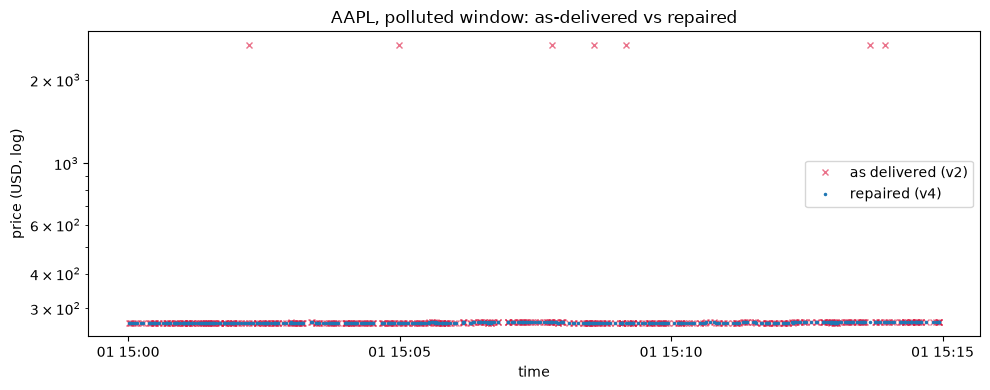

In [17]:
import matplotlib.pyplot as plt

def aapl_window(version=None):
    return (
        db.table("trades", version=version)
        .filter(
            col("symbol") == "AAPL",
            col("ts") >= W0.isoformat(),
            col("ts") < W1.isoformat(),
        )
        .select("ts", "price")
        .to_pandas()
    )


raw_win, clean_win = aapl_window(version=V_RAW), aapl_window()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw_win["ts"], raw_win["price"], "x", ms=4, color="crimson", alpha=0.6,
        label=f"as delivered (v{V_RAW})")
ax.plot(clean_win["ts"], clean_win["price"], ".", ms=3, color="tab:blue",
        label=f"repaired (v{V_CLEAN})")
ax.set_yscale("log")
ax.set_title("AAPL, polluted window: as-delivered vs repaired")
ax.set_xlabel("time")
ax.set_ylabel("price (USD, log)")
ax.legend()
fig.tight_layout()

## 6. Over-cleaned? `restore()` is the undo button

Suppose an eager second pass deletes a window that turns out to be legitimate
volatility.

The deletion is just another version, so rolling back is `restore()`, which
moves the head *forward* to a new version holding the old content. Nothing is
ever lost, including the mistake itself.

In [18]:
bad0 = int(pd.Timestamp("2026-06-02 14:00", tz="UTC").value // 1_000)
bad1 = int(pd.Timestamp("2026-06-02 14:10", tz="UTC").value // 1_000)
oops = db.plan_delete_range("trades", bad0, bad1, note="overzealous: deleting real volatility")
oops.apply()
n_rows = lambda: db.table("trades").select(count_star().alias("n")).to_pandas().n[0]
print("rows after over-delete:", n_rows())

db.restore("trades", V_CLEAN)
print("rows after restore:   ", n_rows())
[{k: v[k] for k in ("sequence", "op", "rows", "note") if k in v} for v in db.versions("trades")[-3:]]

rows after over-delete: 114032
rows after restore:    118213


[{'sequence': 4,
  'op': 'replace_range',
  'rows': 118213,
  'note': 'repair 15:00-15:15 window: /10 fat fingers, drop zeros+dups'},
 {'sequence': 5,
  'op': 'delete_range',
  'rows': 114032,
  'note': 'overzealous: deleting real volatility'},
 {'sequence': 6,
  'op': 'restore',
  'rows': 118213,
  'note': 'restore of version 4'}]

## 7. Lock the table down: plans only

On a shared research database you want *nobody* running unreviewed destructive
writes: not a junior, not a cron job, not an LLM agent.

`set_policy` gates the direct mutation paths. The plan/apply flow keeps
working, because it forces a previewable, noted, atomic commit. A gated call
raises `PolicyError` with a machine-readable code and a remediation hint.

In [19]:
print("policy before:", db.policy())
db.set_policy(direct_write=False, direct_delete=False)

try:
    db.write("trades", db.read("trades"))
except h5i_db.PolicyError as e:
    print(f"\nblocked: code={e.code}\nhint: {e.hint}")

policy before: {'direct_append': True, 'direct_write': True, 'direct_replace': True, 'direct_delete': True, 'direct_restore': True, 'direct_compact': True}

blocked: code=policy_violation
hint: run the write with --plan to preview it, review, then `h5i-db plan apply`; or relax the policy with `h5i-db policy set`


Pending plans are first-class objects too. They show up in `list_plans()` for
teammates to review, survive process restarts, and expire after 7 days if
never applied. Vacuum will not collect segments a live plan references.

In [20]:
pending = db.plan_delete_range("trades", bad0, bad1, note="for review: is 14:00-14:10 real?")
print([(p.plan_id, p.raw["note"]) for p in db.list_plans("trades")])
pending.discard()
print("after discard:", db.list_plans("trades"))

[('eda0c44b-f2ac-44c5-9427-7f3103e323d5', 'for review: is 14:00-14:10 real?')]
after discard: []


## Takeaways

- Each defect class is one SQL query: predicates for zeros and session hours,
  `approx_percentile_cont` medians for fat fingers, GROUP BY with HAVING for
  replayed packets.
- `plan_delete_range` and `plan_replace_range` make corrections *reviewable
  before they happen*, through the summary and before/after samples, then land
  them as atomic, noted commits. Ranges are raw microseconds of the time
  column.
- The version chain is the audit trail. As-delivered data stays queryable via
  `h5i('trades', v)`, diffs are SQL joins, and `restore()` undoes over-cleaning
  without losing the record that it happened.
- `set_policy(direct_write=False, direct_delete=False)` turns "please don't
  hot-fix production tables" from a convention into a `PolicyError`.

In [21]:
db.close()